**개념 정리**

## 7.5 부스팅

부스팅: 약한 학습기를 여러 개 연결하여 강한 학습기를 만드는 앙상블 방법
- 에이다부스트, 그레이디언트 부스팅 등

### 7.5.1 에이다부스트

에이다부스트: 이전 모델이 과소적합했던 훈련 샘플의 가중치를 더 높여 이전 예측기를 보완하는 새로운 예측기를 만듦
- 첫 번째 분류기를 훈련 세트에서 훈련시키고 예측을 만듦 -> 알고리즘이 잘못 분류된 훈련 샘플의 가중치를 상대적으로 높임 -> 두 번째 분류기는 업데이트된 가중치를 사용해 훈련 세트에서 훈련하고 다시 예측을 만듦 -> 가중치 업데이트

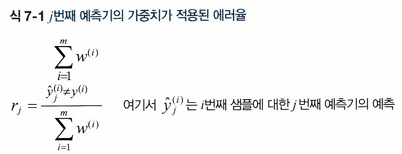

- 각 샘플 가중치는 초기에 1/m로 초기화
- 첫 번째 예측기가 학습되고, 가중치가 적용된 에러율이 훈련 세트에 대해 계산

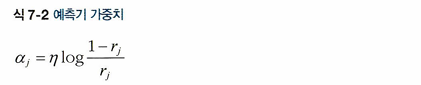

- 예측기가 정확할수록 가중치가 더 높아짐
- 무작위로 예측하는 정도라면 가중치가 0에 가까울 것

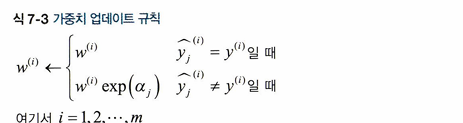

- 샘플의 가중치를 업데이트, 잘못 분류된 샘플의 가중치가 증가
- 업데이트 이후 모든 샘플의 가중치를 정규화

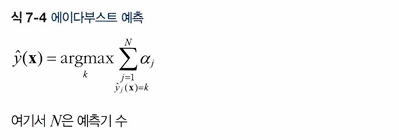

- 예측할 때 단순히 모든 예측기의 예측을 계산하고 예측기 가중치를 더해 예측 결과를 만듦

- 사이킷런은 SAMME라는 에이다부스트의 다중 클래스 버전 사용

### 7.5.2 그레이디언트 부스팅

그레이디언트 부스팅: 앙상블에 이전까지의 오차를 보정하도록 예측기를 순차적으로 추가, 이전 예측기가 만든 잔여 오차에 새로운 예측기를 학습
- GradientBoostingRegressor를 사용하면 GBRT 앙상블 간단하게 훈련 가능
    - learning_rate 매개변수: 각 트리의 기여 정도를 조절
        - 낮게 설정하면 일반적으로 예측 성능이 좋아짐, 축소라고 부르는 규제 방법임
    - staged_predict() 메서드: 훈련의 각 단계에서 앙상블에 의해 만들어진 예측기를 순회하는 반복자를 반환
- 확률적 그레이디언트 부스팅: 각 트리가 훈련할 때 사용할 훈련 샘플의 비율을 지정할 수 있는 방식

## 7.6 스태킹

스태킹: 앙상블에 속한 모든 예측기의 예측을 취합하는 모델을 훈련
- 블렌더: 마지막 예측기
    - 블렌더를 학습시키는 일반적인 방법은 홀드 아웃 세트를 사용하는 것

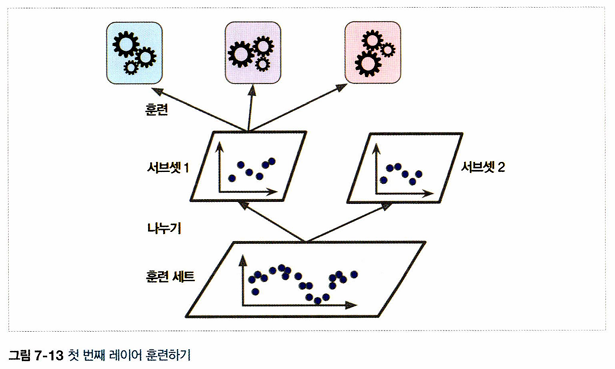

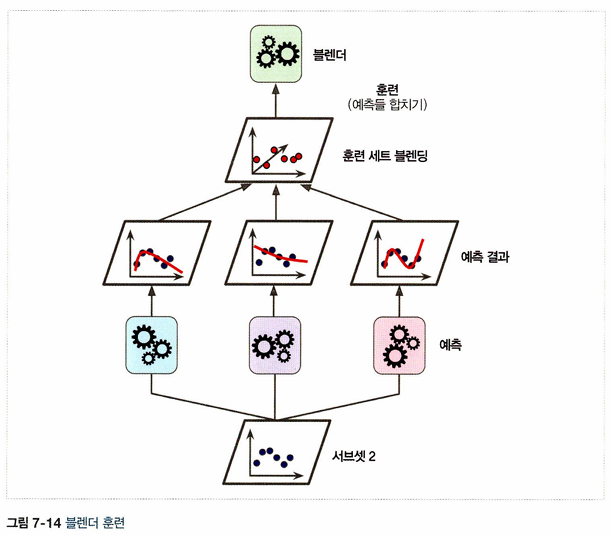

- 훈련 세트를 두 개의 서브셋으로 나누고 첫 번째 레이어의 예측기를 사용해 두 번째 세트에 대한 예측을 만듦
- 홀드 아웃 세트의 각 샘플에 대해 세 개의 예측값이 있음
    - 예측한 값을 입력 특성으로 사용하는 새로운 훈련 세트를 만들 수 있음
    - 블렌더가 새 훈련 세트로 학습

**코드 필사**

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#import package
import numpy as np
import os

In [3]:
#5장에서의 moons dataset 불러오기
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
X, y=make_moons(n_samples=100, noise=0.15)
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2)

에이다부스트

In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_clf=AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=200,
    algorithm="SAMME", learning_rate=0.5)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200)

그레이디언트 부스팅

In [5]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1=DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X,y)

DecisionTreeRegressor(max_depth=2)

In [6]:
y2=y-tree_reg1.predict(X)
tree_reg2=DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X,y2)

DecisionTreeRegressor(max_depth=2)

In [7]:
y3=y2-tree_reg2.predict(X)
tree_reg3=DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X,y3)

DecisionTreeRegressor(max_depth=2)

In [8]:
#y_pred=sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt=GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0)
gbrt.fit(X,y)

GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3)

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val=train_test_split(X, y)

gbrt=GradientBoostingRegressor(max_depth=2, n_estimators=120)
gbrt.fit(X_train, y_train)

errors=[mean_squared_error(y_val, y_pred)
        for y_pred in gbrt.staged_predict(X_val)]
bst_n_estimators=np.argmin(errors)+1

gbrt_best=GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=np.int64(68))

In [11]:
gbrt=GradientBoostingRegressor(max_depth=2, warm_start=True)

min_val_error=float("inf")
error_going_up=0
for n_estimators in range(1,120):
    gbrt.n_estimators=n_estimators
    gbrt.fit(X_train, y_train)
    y_pred=gbrt.predict(X_val)
    val_error=mean_squared_error(y_val, y_pred)
    if val_error < min_val_error:
        min_val_error=val_error
        error_going_up=0
    else:
        error_going_up+=1
        if error_going_up==5:
            break #조기 종료

In [12]:
import xgboost

xgb_reg=xgboost.XGBRegressor()
xgb_reg.fit(X_train, y_train)
y_pred=xgb_reg.predict(X_val)

In [13]:
xgb_reg=xgboost.XGBRegressor(early_stopping_rounds=2)
xgb_reg.fit(X_train, y_train,
            eval_set=[(X_val, y_val)])
y_pred=xgb_reg.predict(X_val)

[0]	validation_0-rmse:0.42337
[1]	validation_0-rmse:0.37447
[2]	validation_0-rmse:0.31396
[3]	validation_0-rmse:0.27499
[4]	validation_0-rmse:0.24349
[5]	validation_0-rmse:0.22493
[6]	validation_0-rmse:0.20883
[7]	validation_0-rmse:0.19960
[8]	validation_0-rmse:0.19824
[9]	validation_0-rmse:0.19379
[10]	validation_0-rmse:0.19261
[11]	validation_0-rmse:0.19217
[12]	validation_0-rmse:0.19017
[13]	validation_0-rmse:0.18849
[14]	validation_0-rmse:0.18570
[15]	validation_0-rmse:0.18563
[16]	validation_0-rmse:0.18545
[17]	validation_0-rmse:0.18383
[18]	validation_0-rmse:0.18275
[19]	validation_0-rmse:0.18210
[20]	validation_0-rmse:0.18174
[21]	validation_0-rmse:0.18152
[22]	validation_0-rmse:0.18132
[23]	validation_0-rmse:0.18136
[24]	validation_0-rmse:0.18138
